In [2]:
import os
import sys
import itertools
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import layers


from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, precision_score

from tensorflow.keras import regularizers
from itertools import product

2025-07-06 09:10:37.116847: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-06 09:10:37.123362: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751803837.130603  153909 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751803837.132941  153909 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751803837.138897  153909 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print("GPU Available:", gpus)
print("cuDNN Enabled:", tf.test.is_built_with_cuda())

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
cuDNN Enabled: True


In [4]:
sys.path.insert(0, "../../")
from config import RESULTS_PATH, CROPPED_PATH, MODELS_PATH

# Paths
TRAIN_PATH = os.path.join(CROPPED_PATH, 'classification_v2', 'train')
VALIDATION_PATH = os.path.join(CROPPED_PATH, 'classification_v2', 'valid')
TEST_PATH = os.path.join(CROPPED_PATH, 'classification_v2', 'test')
ENCODER_PATH = os.path.join(MODELS_PATH, 'encoder', 'encoder_SSIM_MAE_Bparams.keras')

RESULT_PATH = os.path.join(RESULTS_PATH, 'results_encoder_SSIM+MAE.xlsx')
MODEL_PATH = os.path.join(MODELS_PATH, 'supervised')

# Configuration
SHAPE = (128,128,1)
BATCH_SIZE = 32
TRAIN_ENCODER = False
COLOR_MODE="grayscale"
results = []


In [ ]:
def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues):

    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=25)
    #plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90, fontsize=15)
    plt.yticks(tick_marks, classes, fontsize=15)

    fmt = '.2f'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black", fontsize = 14)

    plt.ylabel('True label', fontsize=20)
    plt.xlabel('Predicted label', fontsize=20)


def plot_conf_matrix(model, generator, titulo='Confusion matrix'):
    ### RETRIVE TEST LABEL FROM GENERATOR ###
    test_num = sum(1 for _ in generator)
    label_test = []
    pred_test = []

    for i, batch in enumerate(generator):
        X, y = batch
        label_test.append(y.numpy())
        predictions = model.predict(X, verbose = 0)
        predictions = tf.nn.softmax(predictions, axis=-1)
        pred_test.append(predictions)


    label_test = np.argmax(np.vstack(label_test), axis=1)


    ### COMPUTE PREDICTIONS ON TEST DATA ###
    pred_test = np.argmax(np.vstack(pred_test), axis=1)
    accuracy=accuracy_score(label_test, pred_test)
    recall=recall_score(label_test, pred_test,pos_label=0)
    specificity=recall_score(label_test, pred_test,pos_label=1)
    precision = precision_score(label_test, pred_test, pos_label=0)
    # pred_test = pred_test[:label_test.shape[0],]
    ### ACCURACY ON TEST DATA ###
    print("-" * 40)
    print('ACCURACY:', accuracy)
    print('RECALL:',recall)
    print('PRECISION:', precision)
    print('SPECIFICITY:',specificity)
    print("-" * 40)
    print("\n")
    ### CONFUSION MATRIX ON TEST DATA ###
    cnf_matrix = confusion_matrix(label_test, pred_test)
    results.append({'Model': titulo, 'Accuracy': accuracy , 'Recall':recall,'Precision':precision,'Specificity':specificity})

    plt.figure(figsize=(7,7))
    plot_confusion_matrix(cnf_matrix, classes=['cell', 'not'], title=titulo)
    plt.title(titulo)
    plt.show()


def get_model(pretrain_encoder,TRAIN_ENCODER,input_shape,dropout_rate, l2_reg):
    # encoder=pretrain_encoder

    inp = keras.Input(shape=input_shape)
    x = inp

    # encoder.trainable = TRAIN_ENCODER

    # x = encoder(x)
    x = layers.Flatten()(x)  # <-- Add this line
    x = layers.Dropout(dropout_rate)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(8, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(4, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(x)
    out =layers.Dense(2, activation='linear')(x)


    model = keras.Model(inp, out)

    return model

In [6]:
def data_gen():
    """
    Genera y preprocesa los datasets de entrenamiento, validación y test
    para un modelo de clasificación de imágenes.
    """

    # Función auxiliar para crear y preprocesar un generador de datos
    def create_and_preprocess_generator(path, shuffle=True):
        generator = tf.keras.utils.image_dataset_from_directory(
            path,
            labels="inferred",
            label_mode="categorical",
            batch_size=BATCH_SIZE,
            image_size=(SHAPE[0], SHAPE[1]),
            color_mode=COLOR_MODE,
            shuffle=shuffle,
            seed=42 # Mantener la semilla para reproducibilidad
        )
        generator = generator.map(
            lambda x, y: (x / 255.0, y),
            num_parallel_calls=tf.data.AUTOTUNE
        )
        generator = generator.prefetch(buffer_size=tf.data.AUTOTUNE)
        return generator

    # Crear generadores para entrenamiento, validación y test
    train_generator = create_and_preprocess_generator(TRAIN_PATH, shuffle=True)
    validation_generator = create_and_preprocess_generator(VALIDATION_PATH, shuffle=False) # No es necesario shuffear la validación

    # El test set no necesita shuffe y puede cargarse solo una vez si la función se usa para retornar todo
    test_generator = create_and_preprocess_generator(TEST_PATH, shuffle=False)

    return train_generator, validation_generator, test_generator


Found 12228 files belonging to 2 classes.
(32, 128, 128, 1)
(32, 2)


I0000 00:00:1751803839.704466  153909 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21597 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


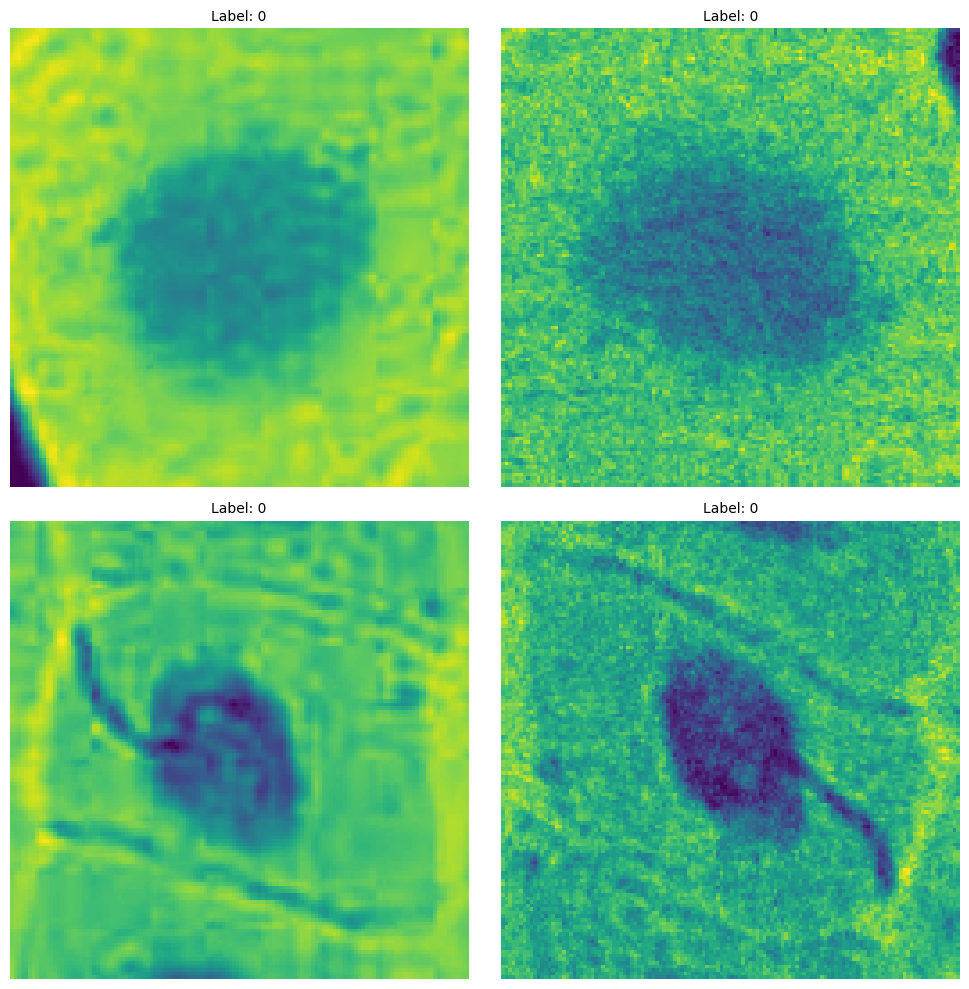

['d', 'nd']

In [7]:
# plot images
train_generator = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    labels="inferred",
    label_mode="categorical",
    batch_size=BATCH_SIZE,
    image_size=(SHAPE[0], SHAPE[1]),
    color_mode=COLOR_MODE,
    shuffle=False,
)

for images, labels in train_generator:
    print(images.shape)
    print(labels.shape)

    #filenames_in_batch = [train_generator.filenames[idx] for idx in train_generator.index_array]

    plt.figure(figsize=(10, 10))

    for i in range(4):
        ax = plt.subplot(2, 2, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))

        #file_name = filenames_in_batch[i]
        label = np.argmax(labels[i])
        plt.title(f"Label: {label}", fontsize=10)

        plt.axis("off")

    plt.tight_layout()
    plt.show()
    break

train_generator.class_names

In [8]:
train_generator,validation_generator,test_generator=data_gen()


Found 12228 files belonging to 2 classes.
Found 3488 files belonging to 2 classes.
Found 1764 files belonging to 2 classes.


In [62]:
from keras import layers, Model
import keras # Importar keras directamente para optimizers y losses

# --- Configuración de Parámetros ---
initial_filters = 32
kernel_size = (3, 3) 
num_classes = 2 
l2 = 0.003

# --- Construcción del Modelo ---
input_layer = layers.Input(shape=(128, 128, 1))

x = input_layer 

# Bloque Convolucional 1
x = layers.Conv2D(initial_filters, kernel_size, activation='relu', padding='same', kernel_regularizer=keras.regularizers.l2(l2))(input_layer)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D((2, 2), padding='same')(x)
x = layers.Dropout(0.25)(x) # Añadido Dropout después del MaxPooling para regularización

# Bloque Convolucional 2
# Duplicar filtros es una práctica común para capturar características más complejas
x = layers.Conv2D(initial_filters * 2, kernel_size, activation='relu', padding='same', kernel_regularizer=keras.regularizers.l2(l2))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D((2, 2), padding='same')(x)
x = layers.Dropout(0.25)(x)

# Bloque Convolucional 3
x = layers.Conv2D(initial_filters * 4, kernel_size, activation='relu', padding='same', kernel_regularizer=keras.regularizers.l2(l2))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D((2, 2), padding='same')(x)
x = layers.Dropout(0.25)(x) # Aumentar ligeramente el Dropout

# Bloque Convolucional 4 (Opcional, dado el tamaño de imagen)
# Para imágenes de 128x128, 3-4 bloques suelen ser suficientes.
x = layers.Conv2D(initial_filters * 8, kernel_size, activation='relu', padding='same', kernel_regularizer=keras.regularizers.l2(l2))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D((2, 2), padding='same')(x)
x = layers.Dropout(0.3)(x)

# Bloque Convolucional 5 (Probablemente innecesario para 128x128 con 4x MaxPools)
# Si lo mantienes, las dimensiones de la imagen serán muy pequeñas aquí.
# x = layers.Conv2D(initial_filters * 16, kernel_size, activation='relu', padding='same', kernel_regularizer=keras.regularizers.l2(l2))(x)
# x = layers.BatchNormalization()(x)
# x = layers.MaxPool2D((2, 2), padding='same')(x)
# x = layers.Dropout(0.3)(x)

# Capas Densely Connected (Clasificador)
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.004))(x) # Aumentar neuronas en la capa Dense
x = layers.Dropout(0.4)(x) # Aumentar Dropout en la capa Dense

# Capa de Salida
# Para 2 clases y 'CategoricalCrossentropy(from_logits=True)', 'linear' es correcto.
# Si usarías 'CategoricalCrossentropy' (sin from_logits=True), necesitarías 'softmax'.
output_layer = layers.Dense(num_classes, activation='linear')(x)

model = Model(inputs=input_layer, outputs=output_layer)

model.summary() # Muestra un resumen de la arquitectura del modelo

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_72          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_72 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_90 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_73          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_73 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_91 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_74 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_74          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_74 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_92 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_75          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_75 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_93 (Dropout)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │     1,048,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_94 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,438,530 (5.49 MB)

 Trainable params: 1,437,570 (5.48 MB)

 Non-trainable params: 960 (3.75 KB)

In [63]:
# --- Compilación del Modelo ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4), # Especificar learning_rate
    loss=keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# --- Callbacks ---
stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=8, # Aumentar paciencia para dar más oportunidades al modelo
    verbose=1, # Cambiar a 1 para ver mensajes cuando se detiene
    mode="min", # Asegurarse que es 'min' para val_loss
    restore_best_weights=True,
    start_from_epoch=2,
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

# --- Entrenamiento del Modelo ---
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=validation_generator,
    callbacks=[stopping, reduce_lr], # Activar el callback EarlyStopping
    verbose=1
)

Epoch 1/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7902 - loss: 1.9666 - val_accuracy: 0.6909 - val_loss: 3.3414 - learning_rate: 1.0000e-04
Epoch 2/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8634 - loss: 1.6241 - val_accuracy: 0.8592 - val_loss: 1.5418 - learning_rate: 1.0000e-04
Epoch 3/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8641 - loss: 1.4791 - val_accuracy: 0.8271 - val_loss: 1.4461 - learning_rate: 1.0000e-04
Epoch 4/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8704 - loss: 1.3240 - val_accuracy: 0.7511 - val_loss: 1.6380 - learning_rate: 1.0000e-04
Epoch 5/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8739 - loss: 1.1907 - val_accuracy: 0.8065 - val_loss: 1.1953 - learning_rate: 1.0000e-04
Epoch 6/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8766 - loss: 1.0659 - val_accuracy: 0.7856 - val_loss: 1.1448 - learning_rate: 1.0000e-04
Epoch 7/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - ac

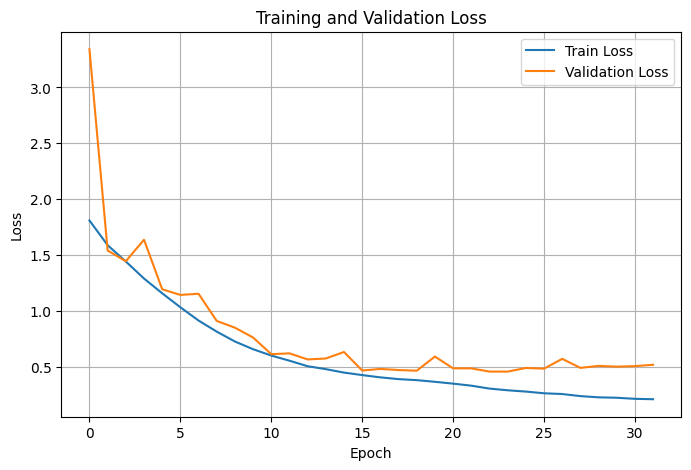

In [64]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━

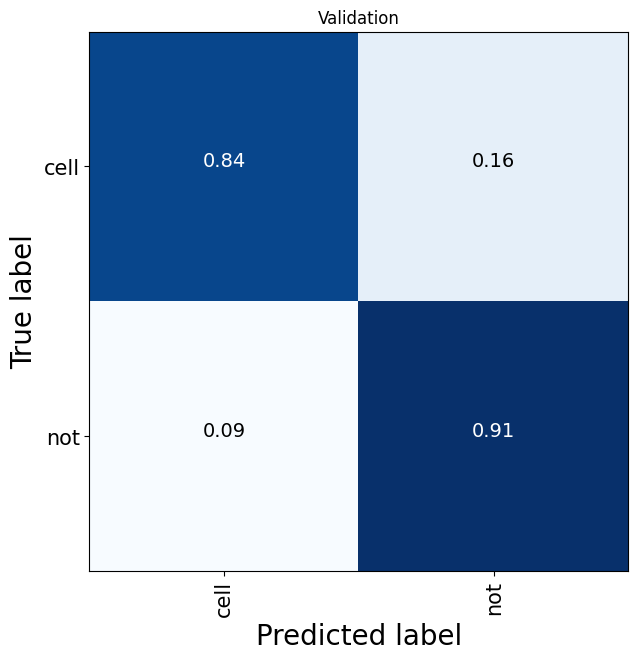


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━

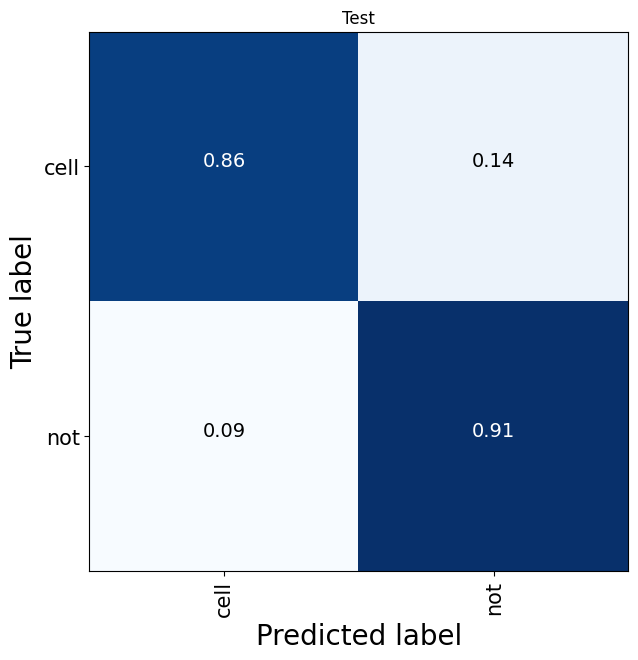

In [65]:
os.makedirs(MODEL_PATH, exist_ok=True)
model.save(os.path.join(MODEL_PATH, f'classifier.keras'))
plot_conf_matrix(model, validation_generator, 'Validation')
print()
plot_conf_matrix(model, test_generator, 'Test')